In [1]:
import numpy as np
import xarray as xr
import rioxarray 

In [3]:
s2b_data = rioxarray.open_rasterio(r"C:\Users\sfreeman\Downloads\S2B_MSIL2A_20260225T163149_N0512_R083_T16SFJ_20260225T215442.SAFE\S2B_MSIL2A_20260225T163149_N0512_R083_T16SFJ_20260225T215442.SAFE\GRANULE\L2A_T16SFJ_A046870_20260225T163318\IMG_DATA\R10m\T16SFJ_20260225T163149_TCI_10m.jp2")

In [15]:
B4_data = rioxarray.open_rasterio(r'C:\Users\sfreeman\Downloads\S2B_MSIL2A_20260225T163149_N0512_R083_T16SFJ_20260225T215442.SAFE\S2B_MSIL2A_20260225T163149_N0512_R083_T16SFJ_20260225T215442.SAFE\GRANULE\L2A_T16SFJ_A046870_20260225T163318\IMG_DATA\R10m\T16SFJ_20260225T163149_B04_10m.jp2')

In [4]:
s2b_data

<xarray.DataArray (band: 3, y: 10980, x: 10980)> Size: 362MB
[361681200 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 88kB 4.4e+06 4.4e+06 4.4e+06 ... 4.29e+06 4.29e+06
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [16]:
B4_data

<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
[120560400 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 4.4e+06 4.4e+06 4.4e+06 ... 4.29e+06 4.29e+06
  * x            (x) float64 88kB 6e+05 6e+05 6e+05 ... 7.098e+05 7.098e+05
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

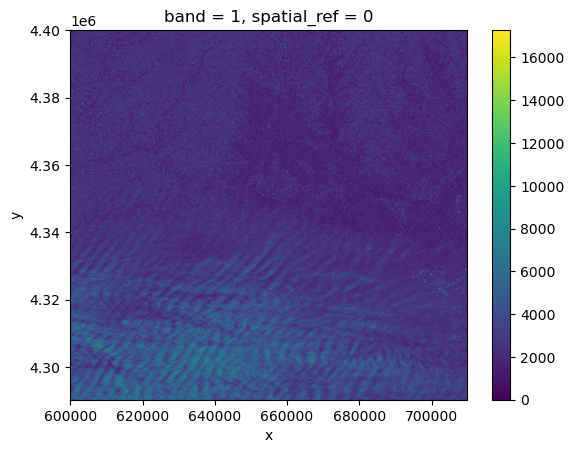

In [17]:
B4_data.plot()

In [19]:
normed_b4 = (B4_data/B4_data.max())*256

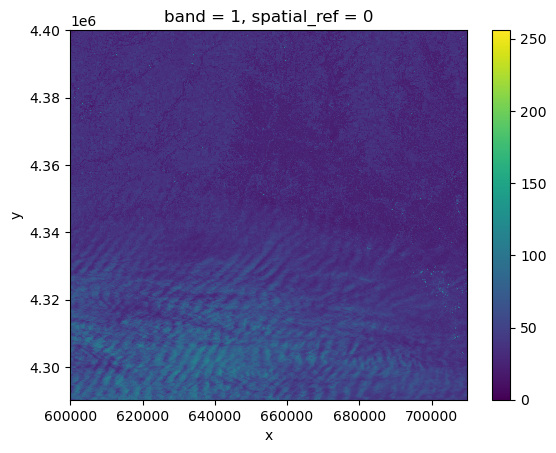

In [20]:
normed_b4.plot()

In [21]:
ndvi = (s2b_data[0]-normed_b4)/(s2b_data[0]+normed_b4)

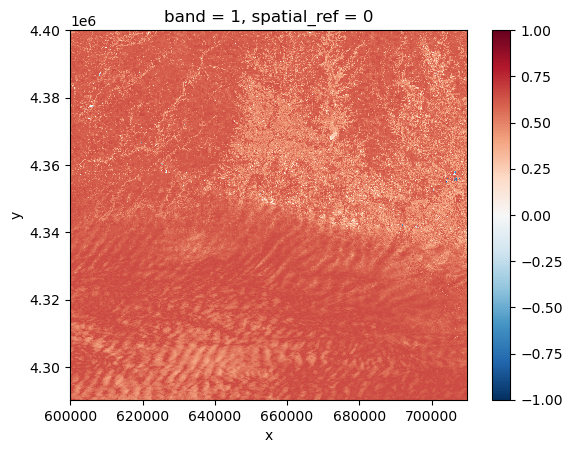

In [22]:
ndvi.plot()

In [5]:
s2b_data['band']

<xarray.DataArray 'band' (band: 3)> Size: 24B
array([1, 2, 3])
Coordinates:
  * band         (band) int64 24B 1 2 3
    spatial_ref  int64 8B 0

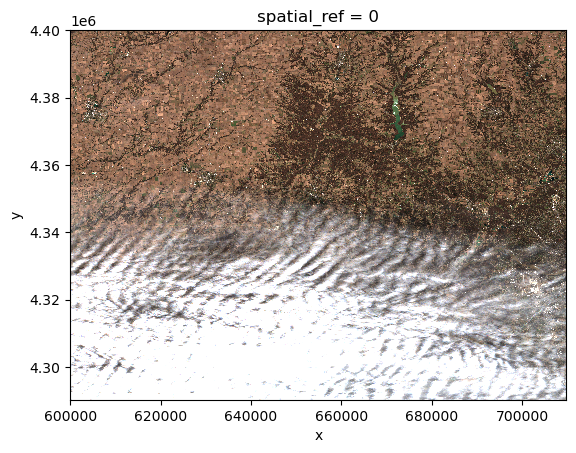

In [14]:
s2b_data.plot.imshow(rgb="band")

In [8]:
s2b_data.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32616"]]')

In [11]:
lat_lon_s2b = s2b_data.rio.reproject("EPSG:4326")

In [12]:
lat_lon_s2b

<xarray.DataArray (band: 3, y: 9766, x: 12561)> Size: 368MB
array([[[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]]],
      shape=(3, 9766, 12561), dtype=uint8)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 78kB 39.74 39.74 39.74 39.74 ... 38.74 38.74 38.74
  * x            (x) float64 100kB -85.85 -85.85 -85.85 ... -84.55 -84.55 -84.55
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    255

In [ ]:
# 